
# Seminární práce 1, úloha 2
## Počítačové zpracování signálů(KI/PZS)

Autor: Rafael Gumerov (F24635)


# Vypočet korelaci mezi jejich EKG, ABP a ICP signálem

In [1]:
import numpy as np
import pandas as pd
import wfdb
import scipy.signal as signal
import matplotlib.pyplot as plt
import os
import seaborn as sns

## Helper: plot_signals()

In [50]:
def plot_signals(time_axis, signals_dict, fs, title="Signals", start_sec = 10, end_sec = 14):
    """
    Vykreslí zadané signály v časovém rozsahu.
    
    Parametry:
    - time_axis: časová osa
    - signals_dict: slovník ve tvaru {'název': signal_data, ...}
    - start_sec: začátek v sekundách
    - end_sec: konec v sekundách
    - fs: vzorkovací frekvence
    - title: nadpis grafu
    """
    start_idx = int(start_sec * fs)
    end_idx = int(end_sec * fs)
    
    plt.figure(figsize=(12, 4))
    
    for name, signal in signals_dict.items():
        plt.plot(time_axis[start_idx:end_idx], signal[start_idx:end_idx], 
                label=name, alpha=0.7)
    
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.xlabel('Čas (s)')
    plt.ylabel('Amplituda')
    plt.show()

### 1. Nastavil jsem původní soubor a zvolil charis4 pro ověření správnosti načtení.

In [35]:
base_folder = "./data/charis-database-1.0.0"
record_path = os.path.join(base_folder, "charis4")

signals, fields = wfdb.rdsamp(record_path)

print(fields)
fs = fields["fs"]
signal_names = fields["sig_name"]
print(fs, signal_names)


{'fs': 50, 'sig_len': 7199999, 'n_sig': 3, 'base_date': None, 'base_time': None, 'units': ['mmHg', 'mV', 'mmHg'], 'sig_name': ['ABP', 'ECG', 'ICP'], 'comments': ['<age>: 44  <sex>: F  <diagnoses>: (CVA)  <outcome>: Rehab']}
50 ['ABP', 'ECG', 'ICP']


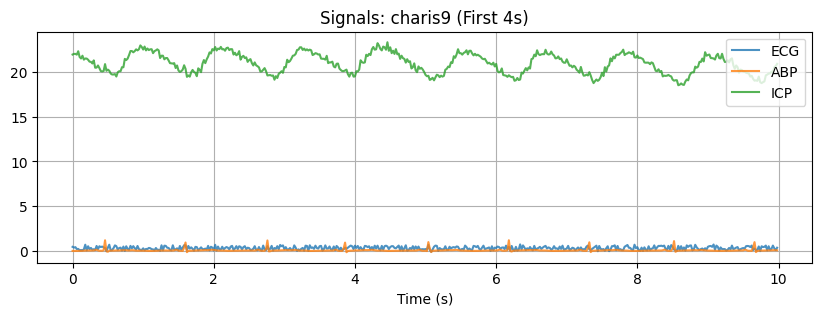

In [36]:

# casova osa
time_axis = np.arange(len(signals)) / fs

plt.figure(figsize=(10, 3))
# 10 sekund limit
limit = int(10 * fs)
plt.plot(time_axis[:limit], signals[:, 0][:limit], label='ECG', alpha=0.8)
plt.plot(time_axis[:limit], signals[:, 1][:limit], label='ABP', alpha=0.8)
plt.plot(time_axis[:limit], signals[:, 2][:limit], label='ICP', alpha=0.8)
plt.legend(loc='upper right')
plt.title(f"Signals: {pacient} (First 4s)")
plt.xlabel("Time (s)")
plt.grid(True)
plt.show()

Dozvěděl jsem se, že jednotlivé ABP, ECG a ICP signály se dají dostat pomocí položky **sig_name**.

Jak je vidět na grafu, signály nejsou centralizované. 
## 2. Vytvořím metodu `get_and_process_signal()`, která:

- Extrahuje data požadovaného signálu
- Ořízne signál na 30 minut
- Ošetří chybějící hodnoty NaNs (nahrazením průměrem, nikoliv interpolací)
- Provede centralizaci signálu (odečtením střední hodnoty)
- Převzorkuje signál na novou frekvenci, pokud je zadána


In [ ]:
def get_and_process_signal(signals, fs, signal_names, target_signal, new_fs=None):
    
    if target_signal not in signal_names:
        print(f"⚠️ Signál '{target_signal}' nenalezen.")
        return None, None

    # Extrakce dat
    idx = signal_names.index(target_signal)
    sig = signals[:, idx].flatten()

    # Oříznutí na 1 hodinu
    samples_30min = int(3600 * fs)
    sig = sig[:min(len(sig), samples_30min)]

    # Ošetření NaNs (nahrazení průměrem, nikoliv interpolace)
    if np.isnan(sig).any():
        sig = np.nan_to_num(sig, nan=np.nanmean(sig))

    # Centralizace (odečtení střední hodnoty)
    sig = sig - np.mean(sig)

    if new_fs and new_fs != fs:
        new_len = int(len(sig) * new_fs / fs)
        
        x_old = np.linspace(0, len(sig)-1, len(sig))
        x_new = np.linspace(0, len(sig)-1, new_len)
        
        # Lineární interpolace na novou frekvenci
        sig = np.interp(x_new, x_old, sig)
        fs = new_fs

    return sig, fs

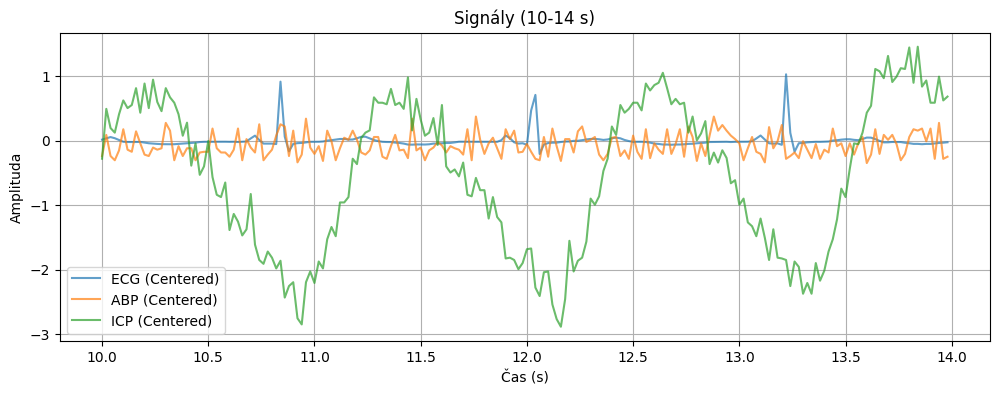

In [51]:
ecg_signal, fs_ecg = get_and_process_signal(signals, fs, signal_names, "ECG")
abp_signal, fs_abp = get_and_process_signal(signals, fs, signal_names, "ABP")
icp_signal, fs_icp = get_and_process_signal(signals, fs, signal_names, "ICP")


# casova osa
time_axis = np.arange(len(ecg_signal)) / fs_ecg

signals_dict = {
    'ECG (Centered)': ecg_signal,
    'ABP (Centered)': abp_signal,
    'ICP (Centered)': icp_signal
}

# Vykreslení pomocí helper funkce
plot_signals(time_axis, signals_dict, fs_ecg, 
             title="Signály (10-14 s)")


Mám velké podezření, že tyto hodnoty musí být vertikálně zarovnány podle svých peaků, protože tyto metriky v lidském těle spolu úzce souvisejí, ale na grafu to není vidět.

## 3. Vytvořím funkci align_signals_by_peak, která:

- Definuje okno pro hledání (např. první 2 sekundy)
- Nalezne index maxima v tomto okně
- Posune signál oříznutím všeho před vrcholem

In [ ]:
def align_signals_by_peak(signal_data, fs, search_window_sec=1.0):
    """
    Posune signál tak, aby dominantní vrchol v úvodním okně byl na indexu 0.
    """

    search_samples = int(search_window_sec * fs)

    peak_idx = np.argmax(signal_data[:search_samples])

    aligned_signal = signal_data[peak_idx:]
    
    return aligned_signal

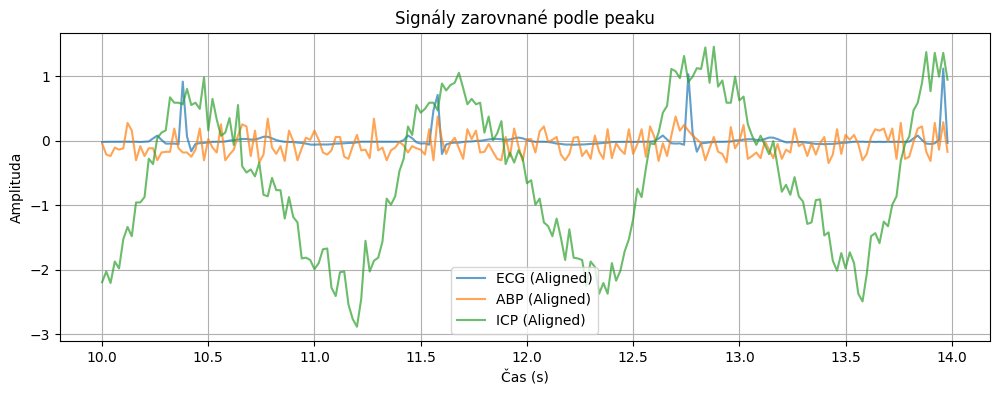

In [73]:
abp_aligned = align_signals_by_peak(abp_signal, fs_abp)
ecg_aligned = align_signals_by_peak(ecg_signal, fs_ecg)
icp_aligned = align_signals_by_peak(icp_signal, fs_icp)


# casova osa
time_axis_sec = np.arange(len(ecg_aligned)) / fs_abp

# Slovník zarovnaných signálů
aligned_dict = {
    'ECG (Aligned)': ecg_aligned,
    'ABP (Aligned)': abp_aligned,
    'ICP (Aligned)': icp_aligned
}

# Vykreslení pomocí helper funkce
plot_signals(time_axis_sec, aligned_dict, fs_abp,
             title="Signály zarovnané podle peaku")


Teď už to vypadá líp, než jsme měli na počátku. Ačkoliv to není ideální zarovnání, ale rozhodně nám zlepší výsledky korelací.

Abych při každém iterování nemusel psát to samé, udělal jsem malý wrapper 
## 4. **preprocess_and_align_all()**, který:

- Extrahuje a předzpracuje signály
- Zarovná je podle prvního dominantního peaku
- Vrátí DataFrame se zarovnanými signály jako sloupce

In [77]:
def preprocess_and_align_all(signals, fs, signal_names, target_signals = None, new_fs=None, search_window_sec=1.0):

    aligned_dict = {}
    last_fs = fs

    if target_signals is None:
        target_signals = signal_names  # zpracovat všechny

    for sig_name in target_signals:
        sig, new_fs_out = get_and_process_signal(signals, fs, signal_names, sig_name, new_fs=new_fs)

        if sig is None:
            continue

        aligned_sig = align_signals_by_peak(sig, new_fs_out, search_window_sec)

        aligned_dict[sig_name] = aligned_sig
        last_fs = new_fs_out

        # Trim all signals to the same length
    if aligned_dict:
        min_len = min(len(arr) for arr in aligned_dict.values())
        for key in aligned_dict:
            aligned_dict[key] = aligned_dict[key][:min_len]
        df_aligned = pd.DataFrame(aligned_dict)
    else:
        df_aligned = pd.DataFrame()

    return df_aligned, last_fs


Helper funkce pro výpočet průměrné koherence mezi dvěma signály ve frekvenčním pásmu 0.5-5 Hz

In [ ]:
def get_mean_coherence(sig1, sig2, fs):
    """Calculates average coherence between 0.5Hz and 5Hz."""
    f, Cxy = signal.coherence(sig1, sig2, fs=fs, nperseg=1024)
    mask = (f >= 0.5) & (f <= 5.0)
    return np.mean(Cxy[mask]) if np.sum(mask) > 0 else 0

## 5. Iterace a získání korelačních hodnot mezi ABP, ICP a ECG u jednotlivých pacientů

Tento blok počítá pro každý záznam pacienta **Spearmanovu korelaci** a **průměrnou spektrální koherenci** mezi signály ECG, ABP a ICP.  


In [80]:

results = []

with open(records_file, "r") as f:
    patient_list = [line.strip() for line in f if line.strip()]

for patient in patient_list:
    try:
        # nahrani
        path = os.path.join(base_folder, patient)
        signals, fields = wfdb.rdsamp(path)
        fs = fields["fs"]
        names = fields["sig_name"]

        aligned_dict, fs = preprocess_and_align_all(
            signals,
            fs,
            names
        )

        # Convert to DataFrame
        df_temp = pd.DataFrame(aligned_dict)

        # Trim to equal length automatically
        df_temp = df_temp.dropna().reset_index(drop=True)

        # Rename columns for easier handling
        df_temp.columns = ["ECG", "ABP", "ICP"]

        # --- METRICS ---
        spearman = df_temp.corr(method="spearman")

        s_ecg_abp = spearman.loc["ECG", "ABP"]
        s_abp_icp = spearman.loc["ABP", "ICP"]
        s_ecg_icp = spearman.loc["ECG", "ICP"]

        c_ecg_abp = get_mean_coherence(df_temp["ECG"].values, df_temp["ABP"].values, fs)
        c_abp_icp = get_mean_coherence(df_temp["ABP"].values, df_temp["ICP"].values, fs)
        c_ecg_icp = get_mean_coherence(df_temp["ECG"].values, df_temp["ICP"].values, fs)

        results.append({
            "Patient": patient,
            "Spearman (ECG-ABP)": s_ecg_abp,
            "Spearman (ABP-ICP)": s_abp_icp,
            "Spearman (ECG-ICP)": s_ecg_icp,
            "Coherence (ECG-ABP)": c_ecg_abp,
            "Coherence (ABP-ICP)": c_abp_icp,
            "Coherence (ECG-ICP)": c_ecg_icp,
        })

    except Exception as e:
        print(f"Skipping {patient}: {e}")

# --- FINAL DATAFRAME ---
df_final = pd.DataFrame(results).set_index("Patient")

display(df_final)


,Spearman (ECG-ABP),Spearman (ABP-ICP),Spearman (ECG-ICP),Coherence (ECG-ABP),Coherence (ABP-ICP),Coherence (ECG-ICP)
Patient,,,,,,
charis10,0.338722,0.124793,0.683452,0.380926,0.464343,0.374418
charis11,0.433348,0.330352,0.406182,0.386291,0.335808,0.777026
charis12,-0.180276,0.015971,0.203630,0.512123,0.006354,0.006180
charis13,0.050771,-0.203760,0.194108,0.124282,0.049685,0.035355
charis1,0.007919,-0.339544,-0.022389,0.003714,0.251206,0.003181
charis2,-0.013635,0.007474,0.221687,0.360602,0.336549,0.765076
charis3,-0.264266,-0.323325,0.855934,0.262798,0.253484,0.795824
charis4,0.006290,0.144861,0.025890,0.004238,0.389708,0.003876
charis5,0.004971,-0.209129,0.014227,0.003396,0.409122,0.003325


Vizualizace:


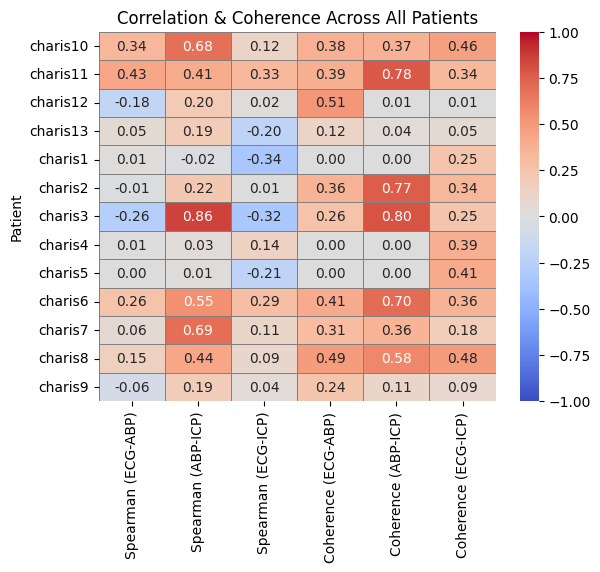

In [70]:
sns.heatmap(
    df_final, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    linewidths=0.5, 
    linecolor='gray'
)

plt.title("Correlation & Coherence Across All Patients")
plt.show()

### Závěr

Heatmapa ukazuje, že mezi signály **ECG, ABP a ICP existují různé úrovně korelace a koherence napříč pacienty**.  
Spearmanova korelace ukazuje monotónní vztahy, zatímco koherence zachycuje společné frekvenční komponenty v pásmu srdeční frekvence (0,5–5 Hz). Ukazují, že mezi signály ECG, ABP a ICP jsou **viditelné vztahy**, přičemž koherence často poskytuje **stabilnější a čitelnější výsledky** než čistá Spearmanova korelace.  
Je však možné, že některé slabší nebo negativní hodnoty jsou způsobeny **nedokonalým zpracováním signálů** (zarovnání, ošetření NaN, resampling), nicméně obecná monotónní a frekvenční souvislost mezi kanály je jasně patrná. 


## 6. Počítání korelací mezi ABP signály všech pacientů.

🎯 Target Sampling Rate established: 50 Hz
✅ Loaded charis10
✅ Loaded charis11
✅ Loaded charis12
✅ Loaded charis13
✅ Loaded charis1
✅ Loaded charis2
✅ Loaded charis3
✅ Loaded charis4
✅ Loaded charis5
✅ Loaded charis6
✅ Loaded charis7
✅ Loaded charis8
✅ Loaded charis9


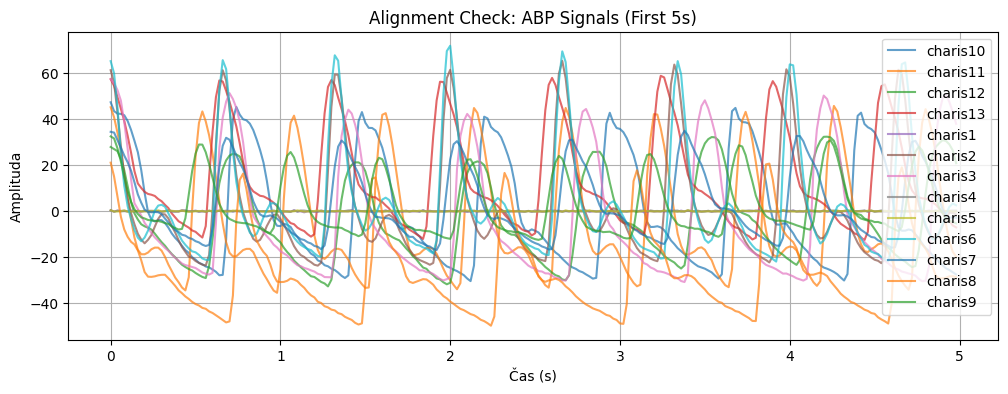

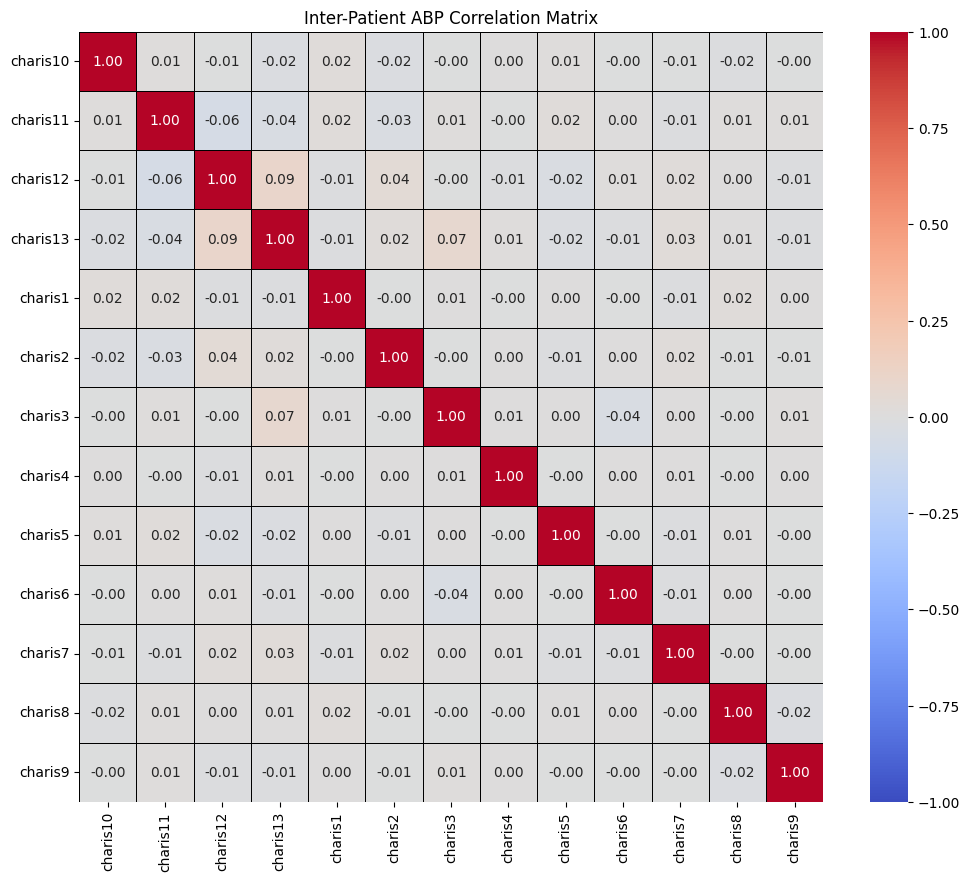

In [82]:
records_file = os.path.join(base_folder, "RECORDS")

abp_master_dict = {}

target_fs = None 

with open(records_file, "r") as f:
    patient_list = [line.strip() for line in f if line.strip()]


for patient in patient_list:
    try:
        # Nahrani dat
        path = os.path.join(base_folder, patient)
        signals, fields = wfdb.rdsamp(path)
        current_fs = fields["fs"]
        names = fields["sig_name"]

        
        if target_fs is None:
            target_fs = current_fs
            print(f"Target Sampling Rate established: {target_fs} Hz")

        # Zpracovani dat
        df_patient, _ = preprocess_and_align_all(
            signals, 
            current_fs, 
            names, 
            target_signals=["ABP"],  # We only care about ABP for this specific task
            new_fs=target_fs,        # Force resampling if needed
            search_window_sec=2.0    # Look for peak in first 2s
        )

        # Ulozeni dat
        if not df_patient.empty and "ABP" in df_patient.columns:
            abp_master_dict[patient] = df_patient["ABP"].values
            print(f"Loaded {patient}")
        else:
            print(f"Skipping {patient}: No ABP signal found.")

    except Exception as e:
        print(f"Error processing {patient}: {e}")



if len(abp_master_dict) > 0:
    # Spolecna delka signalu
    min_len = min(len(arr) for arr in abp_master_dict.values())
    final_data = {k: v[:min_len] for k, v in abp_master_dict.items()}
    
    # Vytvoreni Master DataFrame    
    df_abp_all = pd.DataFrame(final_data)

    # Vypocet korelace
    corr_matrix = df_abp_all.corr()



    # Vizualizace
    signals_dict = df_abp_all.to_dict(orient='list')

    # Casova osa
    time_axis = np.arange(len(df_abp_all)) / target_fs

    # Vykresleni signalu
    plot_signals(
        time_axis=time_axis,       
        signals_dict=signals_dict, 
        fs=target_fs,              
        title="Alignment Check: ABP Signals (First 5s)",
        start_sec=0,               # Start at 0 to see the alignment
        end_sec=5                  # View first 5 seconds
    )

    # HEATMAP (The main requirement)
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap='coolwarm', 
        vmin=-1, vmax=1,
        linewidths=0.5,
        linecolor='black'
    )
    plt.title("Inter-Patient ABP Correlation Matrix")
    plt.show()

else:
    print("No valid ABP signals were loaded.")

## Závěr:

Většina korelačních koeficientů se pohybuje blízko nuly (v rozmezí cca -0.06 až 0.09), což naznačuje velmi slabou nebo žádnou lineární závislost mezi ABP signály různých pacientů.